# Plant Disease Classification using ResNet50 Transfer Learning

This notebook builds an image classification model to detect plant diseases using transfer learning with **ResNet50** (pretrained on ImageNet).

### Key steps:
- **Dataset:** PlantVillage (Pepper, Potato, and Tomato leaf images — 15 classes total)
- **Base model:** ResNet50 with partial fine-tuning (last layers unfrozen)
- **Data augmentation:** random flip, rotation, zoom, and contrast applied on input images
- **Custom classifier head:** combines GlobalAveragePooling and GlobalMaxPooling features, followed by two dense layers with BatchNormalization, LeakyReLU, and Dropout for regularization
- **Training:** Adam optimizer with EarlyStopping and ReduceLROnPlateau callbacks
- **Evaluation:** training/validation accuracy and loss curves, plus single-image prediction

### Goal:
Classify leaf images into one of 15 disease/healthy categories to assist in early plant disease detection.

In [56]:
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/

In [57]:
# !kaggle datasets download -d emmarex/plantdisease

In [58]:
# import zipfile
# zip_ref = zipfile.ZipFile('/content/plantdisease.zip')
# zip_ref.extractall('/content')
# zip_ref.close()


# Library import

In [59]:
import tensorflow as tf
from tensorflow.keras import layers

from tensorflow.keras import models
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    LeakyReLU, Concatenate, Input
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50, EfficientNetB0, InceptionResNetV2

# dataset split

In [60]:
dataset_path = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/'

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'training',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split = .2,
    subset = 'validation',
    seed = 42,
    image_size = (224, 224),
    batch_size = 32
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


# model

In [61]:
base_model = ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

In [62]:
len(base_model.layers)

175

In [63]:
# freeze first layers

for layer in base_model.layers[:140]:
  layer.trainable = False

In [64]:
# unfreeze remaining layers

for layer in base_model.layers[140:]:
  layer.trainable = True

In [65]:
from tensorflow.keras.layers import Concatenate

# Data augmentation layers

data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# Custom classifier

inputs = Input(shape = (224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
gap = GlobalAveragePooling2D()(x)
gmp = GlobalMaxPooling2D()(x)
x = Concatenate()([gap, gmp])

# layer 1
x = Dense(256, kernel_initializer='he_normal', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha = 0.1)(x)
x = Dropout(0.4)(x)

#layer 2
x = Dense(128, kernel_initializer='he_normal', kernel_regularizer=l2(0.001))(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha = 0.1)(x)
x = Dropout(0.3)(x)

# output layer

output = Dense(15, activation='softmax')(x)



In [66]:
from tensorflow.keras.models import Model

model = Model(inputs = inputs, outputs = output)

In [67]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 224, 224,  │          0 │ input_layer_9[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ sequential_3[0][… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 4096)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │  1,048,832 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 256)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ leaky_re_lu_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 128)       │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ leaky_re_lu_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 15)        │      1,935 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,672,911 (94.12 MB)

 Trainable params: 16,062,479 (61.27 MB)

 Non-trainable params: 8,610,432 (32.85 MB)

In [68]:
# Compile

from tensorflow.keras.optimizers import Adam

model.compile(
  optimizer=Adam(learning_rate = 1e-5),
  loss = 'sparse_categorical_crossentropy',
  metrics = ['accuracy']

)

In [69]:
# callbacks

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

reduce_lr = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = .2,
    patience = 3,
    min_lr = 1e-6
)


In [70]:
# train model

histroy = model.fit(
    train_ds,
    validation_data = validation_ds,
    epochs = 20,
    callbacks = [early_stop, reduce_lr]
)

Epoch 1/20


I0000 00:00:1782268594.260773     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


516/516 ━━━━━━━━━━━━━━━━━━━━ 143s 238ms/step - accuracy: 0.3392 - loss: 2.9163 - val_accuracy: 0.6991 - val_loss: 1.9259 - learning_rate: 1.0000e-05
Epoch 2/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.6489 - loss: 1.9884 - val_accuracy: 0.8272 - val_loss: 1.4751 - learning_rate: 1.0000e-05
Epoch 3/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.7692 - loss: 1.6212 - val_accuracy: 0.8827 - val_loss: 1.2650 - learning_rate: 1.0000e-05
Epoch 4/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.8362 - loss: 1.4085 - val_accuracy: 0.9135 - val_loss: 1.1316 - learning_rate: 1.0000e-05
Epoch 5/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.8712 - loss: 1.2750 - val_accuracy: 0.9295 - val_loss: 1.0430 - learning_rate: 1.0000e-05
Epoch 6/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/step - accuracy: 0.8955 - loss: 1.1695 - val_accuracy: 0.9443 - val_loss: 0.9791 - learning_rate: 1.0000e-05
Epoch 7/20
516/516 ━━━━━━━━━━━━━━━━━━━━ 119s 231ms/

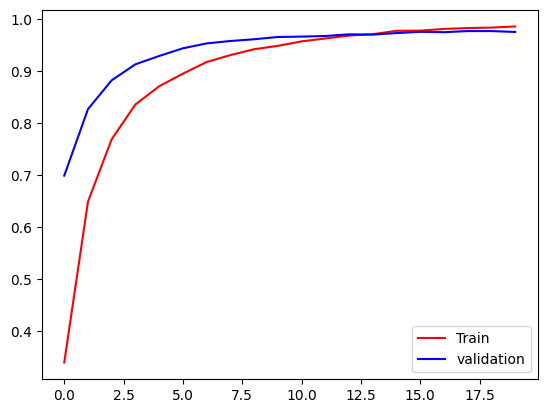

In [71]:

import matplotlib.pyplot as plt

plt.plot(histroy.history['accuracy'], color = 'red', label = "Train")
plt.plot(histroy.history['val_accuracy'], color = 'blue', label = "validation")
plt.legend()
plt.show()

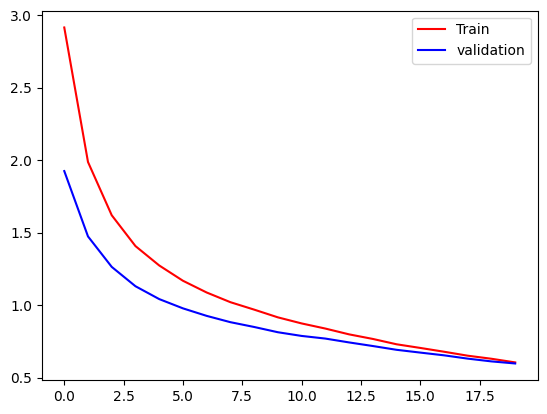

In [72]:
plt.plot(histroy.history['loss'], color = 'red', label = "Train")
plt.plot(histroy.history['val_loss'], color = 'blue', label = "validation")
plt.legend()
plt.show()

## Image load and preprocess

In [75]:
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.utils import img_to_array, load_img
from tensorflow.keras.preprocessing import image
import numpy as np


plant1 = "/kaggle/input/datasets/abdullah65621/plant-image/plant-1.jpg"
plant2 = "/kaggle/input/datasets/abdullah65621/plant-image/plant-2.jpg"
plant3 = "/kaggle/input/datasets/abdullah65621/plant-image/plant-3.jpg"

img = image.load_img(plant3, target_size = (224, 224))
x = img_to_array(img)
x = np.expand_dims(x, axis=0) # (height, width, channels) -> (batch_size, height, width, channels)
x = preprocess_input(x)


In [76]:
print(train_ds.class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [77]:
# prediction
class_name = ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


preds = model.predict(x)

top_index = np.argmax(preds[0])

print("predicted class : ", class_name[top_index])
print("Confidence : ", round(preds[0][top_index] * 100, 2) , "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
predicted class :  Potato___Early_blight
Confidence :  18.28 %
